In [1]:
import torch
print("CUDA khả dụng:", torch.cuda.is_available())
print("Tên thiết bị:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA khả dụng: True
Tên thiết bị: Tesla T4


In [3]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.8 MB/s eta 0:00:00


In [5]:
import wfdb
import numpy as np
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# ==========================================
# CÀI ĐẶT ĐƯỜNG DẪN (Thay đổi cho phù hợp với bạn)
# ==========================================
# Đường dẫn tới thư mục chứa các file 100.dat, 100.hea... của MIT-BIH
MITDB_DIR = '/content/drive/MyDrive/ECG_Project_Data/mitdb' 

# Đường dẫn tới thư mục chứa 3 file nhiễu bw.dat, ma.dat, em.dat của NSTDB
NSTDB_DIR = '/content/drive/MyDrive/ECG_Project_Data/nstdb'

# Thư mục để lưu dataset đầu ra
SAVE_DIR = '/content/drive/MyDrive/ECG_Project_Data/Processed'
os.makedirs(SAVE_DIR, exist_ok=True)

# 2. Cấu trúc chia tập dữ liệu[cite: 2]
SPLITS = {
    'TRAIN': ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', 
              '111', '112', '113', '114', '115', '116', '117', '121', '122', '123', 
              '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', 
              '212', '213', '214', '215'],
    'TEST': ['217', '219', '220', '221', '222', '223', '228'],
    'EVALUATE': ['118', '119', '230', '231', '232', '233', '234']
}

NOISE_SOURCES = ['bw', 'ma', 'em'] # 3 noise records[cite: 1]

def get_noise_signals_offline():
    """Đọc 3 loại nhiễu trực tiếp từ ổ đĩa"""
    noises = {}
    print("Đang đọc dữ liệu nhiễu offline...")
    for noise_name in NOISE_SOURCES:
        # Tạo đường dẫn tới file (không cần đuôi .dat)
        record_path = os.path.join(NSTDB_DIR, noise_name)
        # Đọc trực tiếp từ đường dẫn cục bộ, KHÔNG dùng pn_dir
        record = wfdb.rdrecord(record_path)
        noises[noise_name] = record.p_signal[:, 0]
    return noises

def add_noise_to_ecg(clean_signal, noise_signal, snr=6):
    """Trộn nhiễu vào tín hiệu ECG"""
    if len(noise_signal) > len(clean_signal):
        noise_signal = noise_signal[:len(clean_signal)]
    else:
        repeats = int(np.ceil(len(clean_signal) / len(noise_signal)))
        noise_signal = np.tile(noise_signal, repeats)[:len(clean_signal)]
        
    signal_power = np.mean(clean_signal ** 2)
    noise_power = np.mean(noise_signal ** 2)
    factor = (signal_power / noise_power) / (10 ** (snr / 10.0))
    scaled_noise = noise_signal * np.sqrt(factor)
    
    return clean_signal + scaled_noise

# 3. Thực thi đọc, trộn nhiễu và lưu dataset
noises = get_noise_signals_offline()

for split_name, records in SPLITS.items():
    print(f"\n--- Đang xử lý tập {split_name} ({len(records)} records) ---")
    X_clean, X_noisy = [], []
    
    for rec_id in records:
        print(f"Xử lý record {rec_id}...")
        record_path = os.path.join(MITDB_DIR, rec_id)
        
        # Đọc ECG sạch từ file tải sẵn
        record = wfdb.rdrecord(record_path)
        clean_ecg = record.p_signal[:, 0]
        X_clean.append(clean_ecg)
        
        # Tạo tín hiệu nhiễu
        record_noisy_versions = []
        for n_type in NOISE_SOURCES:
            noisy_ecg = add_noise_to_ecg(clean_ecg, noises[n_type], snr=6)
            record_noisy_versions.append(noisy_ecg)
            
        X_noisy.append(record_noisy_versions)
        
    X_clean = np.array(X_clean)
    X_noisy = np.array(X_noisy)
    
    # 4. Lưu thành file .npy
    clean_path = os.path.join(SAVE_DIR, f'X_clean_{split_name.lower()}.npy')
    noisy_path = os.path.join(SAVE_DIR, f'X_noisy_{split_name.lower()}.npy')
    
    np.save(clean_path, X_clean)
    np.save(noisy_path, X_noisy)
    
    print(f"Đã lưu thành công tập {split_name} vào {SAVE_DIR}")

print("\nHoàn tất tạo dataset offline!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc dữ liệu nhiễu offline...

--- Đang xử lý tập TRAIN (34 records) ---
Xử lý record 100...
Xử lý record 101...
Xử lý record 102...
Xử lý record 103...
Xử lý record 104...
Xử lý record 105...
Xử lý record 106...
Xử lý record 107...
Xử lý record 108...
Xử lý record 109...
Xử lý record 111...
Xử lý record 112...
Xử lý record 113...
Xử lý record 114...
Xử lý record 115...
Xử lý record 116...
Xử lý record 117...
Xử lý record 121...
Xử lý record 122...
Xử lý record 123...
Xử lý record 124...
Xử lý record 200...
Xử lý record 201...
Xử lý record 202...
Xử lý record 203...
Xử lý record 205...
Xử lý record 207...
Xử lý record 208...
Xử lý record 209...
Xử lý record 210...
Xử lý record 212...
Xử lý record 213...
Xử lý record 214...
Xử lý record 215...
Đã lưu thành công tập TRAIN vào /content/drive/MyDrive/ECG_Project_Data/Processed

--- Đang xử lý tập TEST (7 reco

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def preprocess_ecg(clean_data, noisy_data, window_size=1024):
    """Cắt tín hiệu dài thành các đoạn nhỏ và chuẩn hóa Zero-Mean, Unit-Variance"""
    X_clean_segments = []
    X_noisy_segments = []
    
    # Duyệt qua từng record (giả sử noisy_data có shape: [num_records, 3_noises, signal_len])
    for i in range(clean_data.shape[0]):
        clean_signal = clean_data[i]
        
        # Chỉ lấy 1 loại nhiễu để test (ví dụ lấy nhiễu bw - index 0)
        # Bạn có thể gộp cả 3 loại nhiễu vào chung 1 mảng nếu muốn train tổng hợp
        noisy_signal = noisy_data[i][0] 
        
        # Cắt thành các đoạn window_size
        num_windows = len(clean_signal) // window_size
        for w in range(num_windows):
            start = w * window_size
            end = start + window_size
            
            c_seg = clean_signal[start:end]
            n_seg = noisy_signal[start:end]
            
            # Chuẩn hóa Z-score (Standardization)
            c_seg = (c_seg - np.mean(c_seg)) / (np.std(c_seg) + 1e-8)
            n_seg = (n_seg - np.mean(n_seg)) / (np.std(n_seg) + 1e-8)
            
            X_clean_segments.append(c_seg)
            X_noisy_segments.append(n_seg)
            
    # PyTorch yêu cầu input 1D-CNN có dạng [batch_size, channels, length]
    # Do đây là 1 kênh tín hiệu (ECG), channel = 1
    X_c = np.array(X_clean_segments).reshape(-1, 1, window_size)
    X_n = np.array(X_noisy_segments).reshape(-1, 1, window_size)
    
    return torch.tensor(X_n, dtype=torch.float32), torch.tensor(X_c, dtype=torch.float32)

# Load data (Thay đường dẫn của bạn)
X_train_clean = np.load('/content/drive/MyDrive/ECG_Project_Data/Processed/X_clean_train.npy')
X_train_noisy = np.load('/content/drive/MyDrive/ECG_Project_Data/Processed/X_noisy_train.npy')

# Tạo DataLoader
train_noisy_tensor, train_clean_tensor = preprocess_ecg(X_train_clean, X_train_noisy)
train_dataset = TensorDataset(train_noisy_tensor, train_clean_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
print(f"Tổng số mẫu huấn luyện: {len(train_dataset)}")

Tổng số mẫu huấn luyện: 21556


In [ ]:
class Denoise1DCNN(nn.Module):
    def __init__(self):
        super(Denoise1DCNN, self).__init__()
        
        # Encoder: Trích xuất đặc trưng và giảm chiều không gian
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, stride=1, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Decoder: Tái tạo lại tín hiệu sạch từ đặc trưng
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Khởi tạo mô hình, hàm mất mát và bộ tối ưu hóa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Denoise1DCNN().to(device)

criterion = nn.MSELoss() # Dùng Mean Squared Error cho bài toán Denoising
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)


Denoise1DCNN(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 16, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(16, 1, kernel_size=(4,), stride=(2,), padding=(1,))
  )
)
Model checkpoint saved to: models/denoise_ecg_model.pth


Epoch [1/5], Loss: 0.1857
Epoch [2/5], Loss: 0.1308
Epoch [3/5], Loss: 0.1269
Epoch [4/5], Loss: 0.1244
Epoch [5/5], Loss: 0.1226


Đang tiến hành suy luận trên tập Test...

--- KẾT QUẢ ĐÁNH GIÁ (TEST SET) ---
MSE: 0.113877
SNR (Output): 9.44 dB


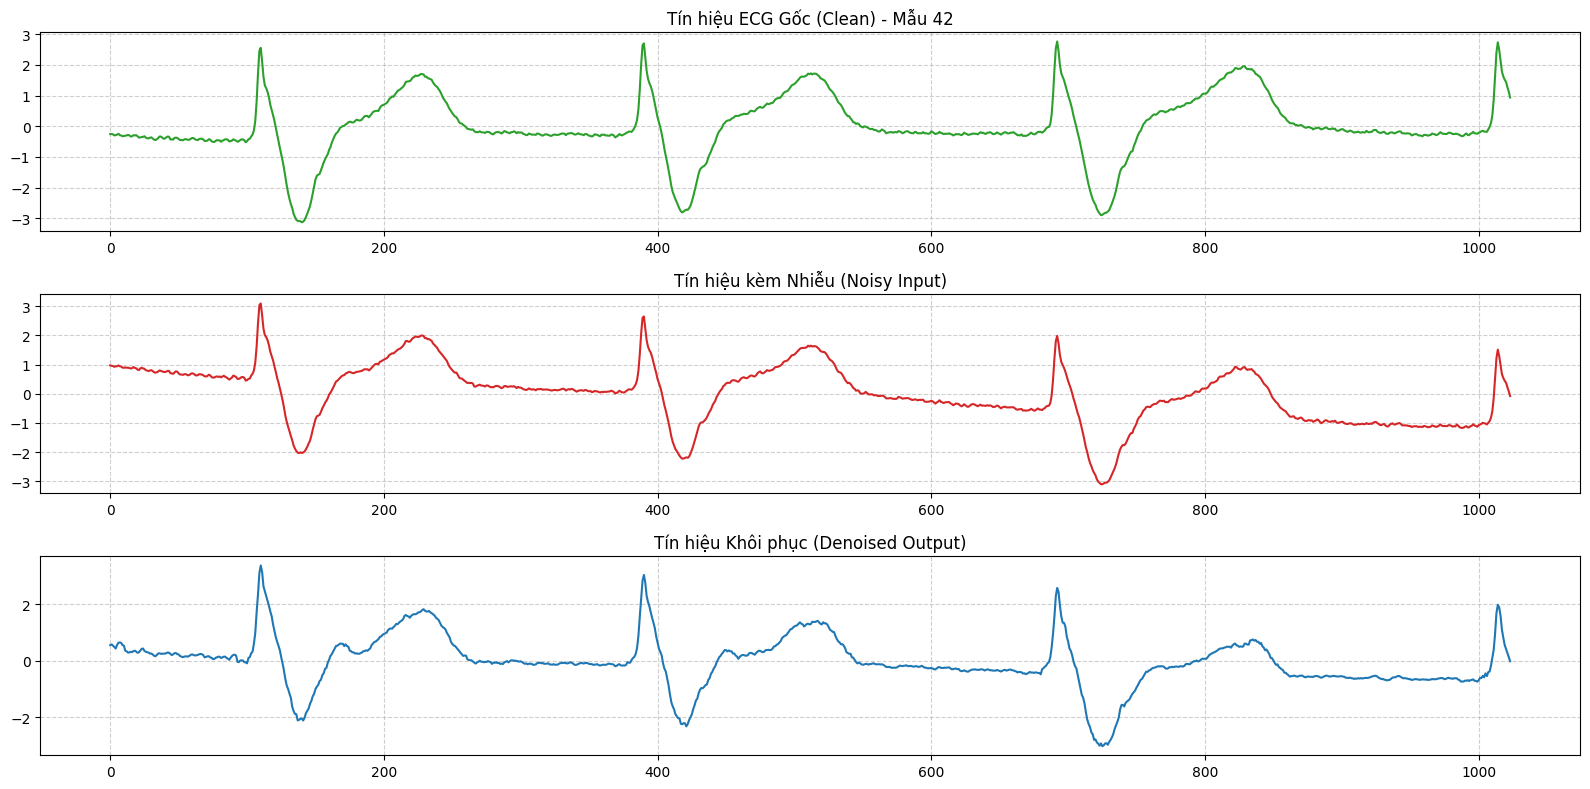

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

def calculate_snr(clean, denoised):
    """Tính chỉ số SNR đầu ra theo dB"""
    signal_power = np.sum(clean ** 2)
    noise_power = np.sum((clean - denoised) ** 2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

# 1. Load dữ liệu TEST (7 record)[cite: 2]
X_test_clean = np.load('/content/drive/MyDrive/ECG_Project_Data/Processed/X_clean_test.npy')
X_test_noisy = np.load('/content/drive/MyDrive/ECG_Project_Data/Processed/X_noisy_test.npy')

# Tái sử dụng hàm preprocess_ecg ở block code trước để cắt window và chuẩn hóa
test_noisy_tensor, test_clean_tensor = preprocess_ecg(X_test_clean, X_test_noisy)
test_dataset = TensorDataset(test_noisy_tensor, test_clean_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Đánh giá mô hình
model.eval()
all_clean = []
all_denoised = []
all_noisy = []

print("Đang tiến hành suy luận trên tập Test...")
with torch.no_grad(): # Vô hiệu hóa gradient để tiết kiệm bộ nhớ và tăng tốc
    for noisy_batch, clean_batch in test_loader:
        noisy_batch = noisy_batch.to(device)
        
        # Dự đoán tín hiệu sạch
        outputs = model(noisy_batch)
        
        # Đưa tensor từ GPU về CPU và chuyển thành numpy array
        all_clean.append(clean_batch.numpy())
        all_denoised.append(outputs.cpu().numpy())
        all_noisy.append(noisy_batch.cpu().numpy())

# Gộp danh sách các batch lại thành mảng 2D (num_samples, window_size)
all_clean = np.concatenate(all_clean).squeeze()
all_denoised = np.concatenate(all_denoised).squeeze()
all_noisy = np.concatenate(all_noisy).squeeze()

# 3. Tính toán các chỉ số định lượng
mse_score = mean_squared_error(all_clean.flatten(), all_denoised.flatten())
snr_score = calculate_snr(all_clean.flatten(), all_denoised.flatten())

print("\n--- KẾT QUẢ ĐÁNH GIÁ (TEST SET) ---")
print(f"MSE: {mse_score:.6f}")
print(f"SNR (Output): {snr_score:.2f} dB")

# 4. Trực quan hóa kết quả (Qualitative Evaluation)
def plot_ecg_comparison(clean, noisy, denoised, sample_idx=0):
    """Vẽ biểu đồ dạng sóng để kiểm tra bằng mắt thường"""
    plt.figure(figsize=(16, 8))
    
    # Biểu đồ 1: Tín hiệu gốc
    plt.subplot(3, 1, 1)
    plt.title(f'Tín hiệu ECG Gốc (Clean) - Mẫu {sample_idx}')
    plt.plot(clean[sample_idx], color='#2ca02c')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Biểu đồ 2: Tín hiệu có nhiễu
    plt.subplot(3, 1, 2)
    plt.title('Tín hiệu kèm Nhiễu (Noisy Input)')
    plt.plot(noisy[sample_idx], color='#d62728')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Biểu đồ 3: Tín hiệu sau khi qua mạng 1D-CNN
    plt.subplot(3, 1, 3)
    plt.title('Tín hiệu Khôi phục (Denoised Output)')
    plt.plot(denoised[sample_idx], color='#1f77b4')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Thay đổi sample_idx để xem các đoạn cắt tín hiệu khác nhau
plot_ecg_comparison(all_clean, all_noisy, all_denoised, sample_idx=42)